In [1]:
import pickle
import os
import numpy as np

def r2(y, p):
    m = ~(np.isnan(y) | np.isnan(p))
    y, p = y[m], p[m]
    return 1 - np.sum((y - p) ** 2) / np.sum((y - np.mean(y)) ** 2)

def analyse_one(temp, fold, md, mt, sat, targets, n_spatial, train_val_test):
    files = [fname for fname in os.listdir('hybrid_outputs') if f'hybrid_Tsense_temp{temp}_fold{fold}_md{md}_mt{mt}_sat{sat}_targets{targets}_' in fname]
    files = sorted(files, key=len)
    with open('hybrid_outputs/'+files[n_spatial], 'rb') as f:
        results = pickle.load(f)
    test_R2s = {}
    for target in targets.split('-'):
        test_idx = results['split'] == train_val_test
        tar = results[f'target_{target}'][test_idx]
        pred = results[f'pred_{target}'][test_idx]
        r2_value = r2(tar.values, pred.values)
        test_R2s[target] = float(r2_value)   
    return test_R2s
        
analyse_one('static', 0, 'MM', 'density_dependent', 'no', 'SOC-MAOC', 1, 'test')

{'SOC': -0.2756321430206299, 'MAOC': -0.036244869232177734}

In [2]:
def get_all_n_sp(temp, fold, md, mt, sat, targets, train_val_test):
    all = []
    for i in range(20):
        try:
            all.append(analyse_one(temp, fold, md, mt, sat, targets, i, train_val_test))
        except:
            pass
    return all

get_all_n_sp('static', 7, 'MM', 'density_dependent', 'no', 'SOC-MAOC', 'test')

[{'SOC': -0.16653180122375488, 'MAOC': -0.026230573654174805},
 {'SOC': -0.27627062797546387, 'MAOC': -0.03529000282287598},
 {'SOC': -0.1967179775238037, 'MAOC': 0.5858967304229736},
 {'SOC': -0.09833037853240967, 'MAOC': 0.680253267288208},
 {'SOC': 0.9499104022979736, 'MAOC': 0.6079585552215576}]

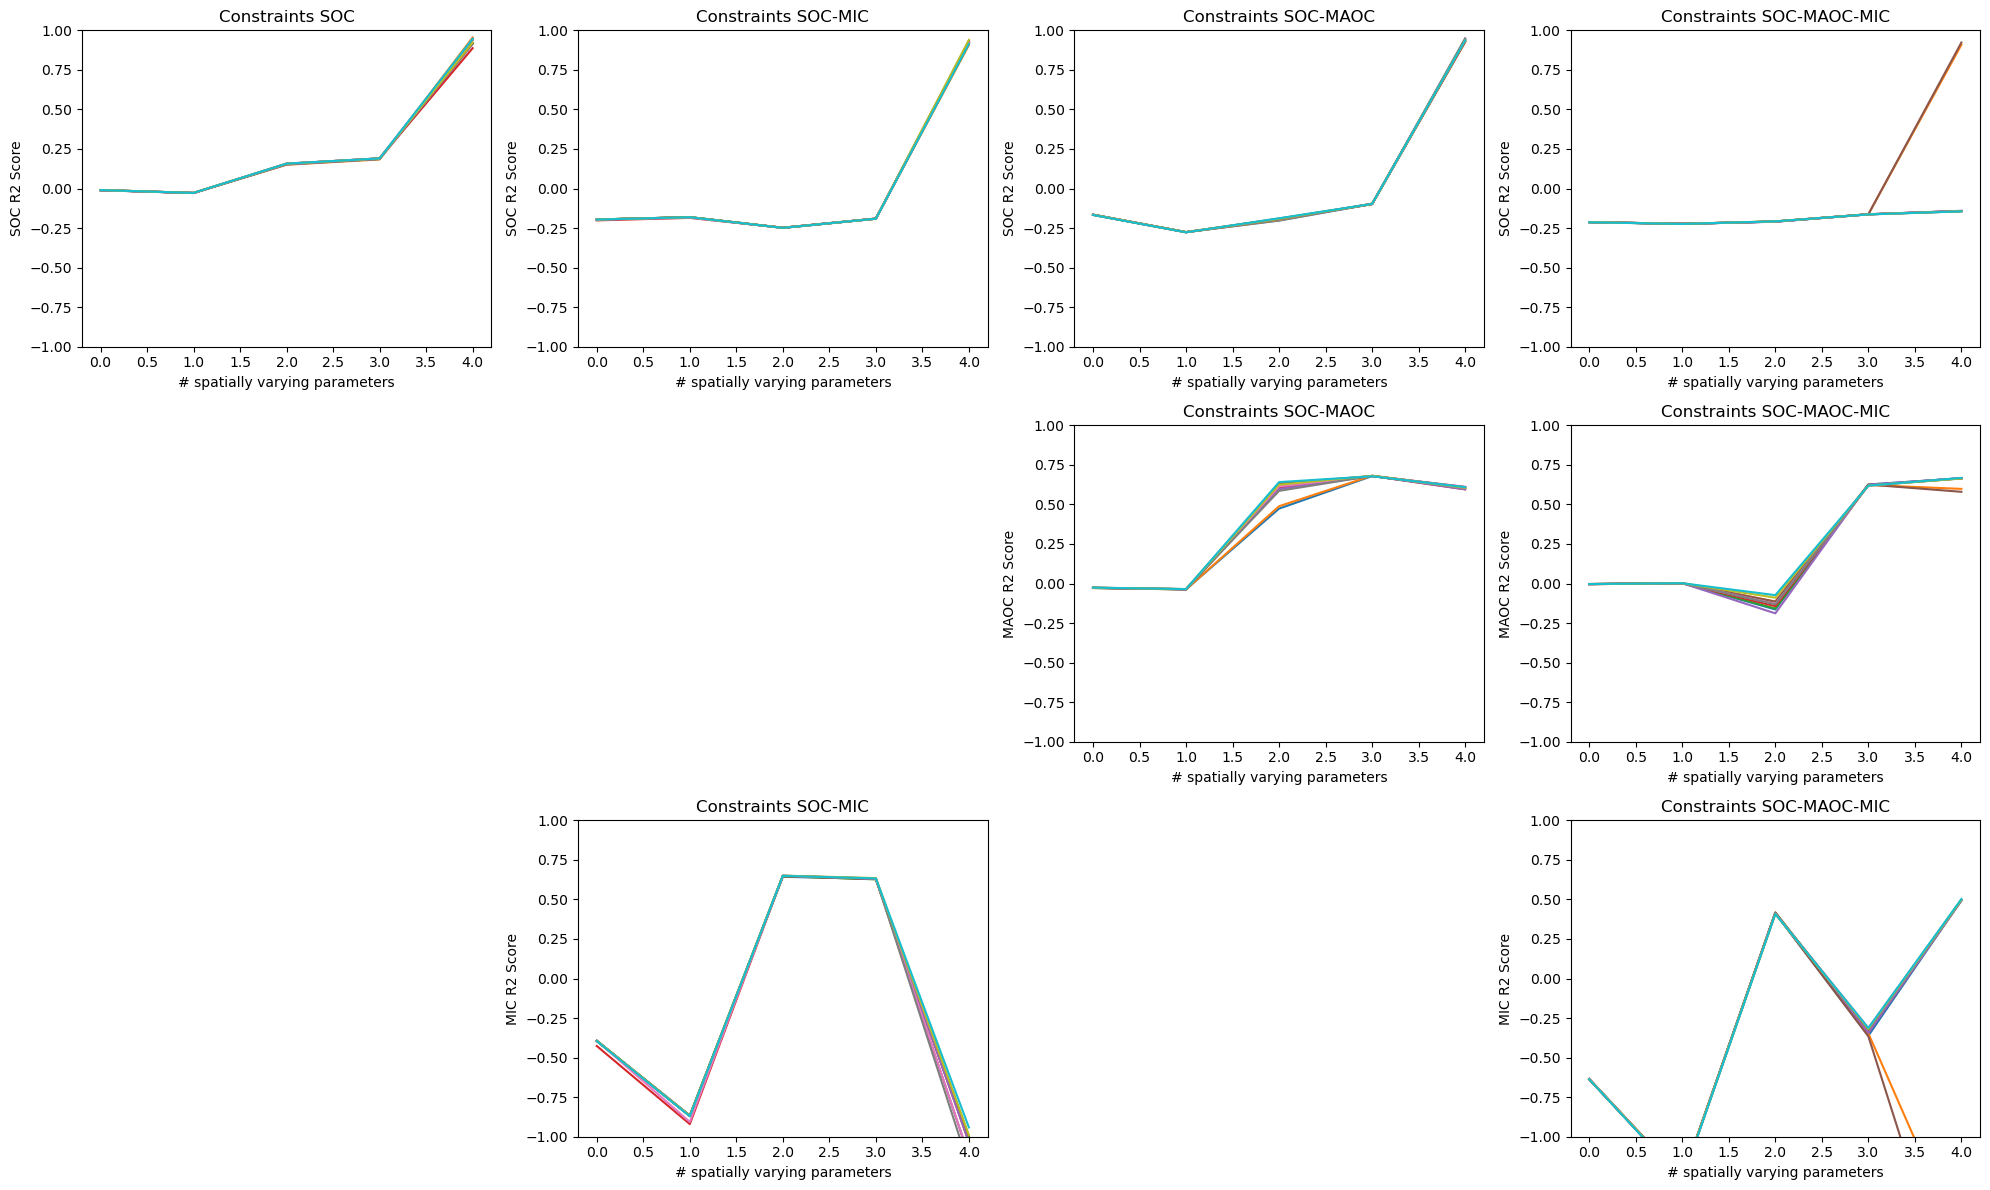

In [3]:
import matplotlib.pyplot as plt

def full_plot(temp, md, mt, sat, train_val_test):
    target_sets = ['SOC', 'SOC-MIC', 'SOC-MAOC', 'SOC-MAOC-MIC']  # 4 columns
    all_targets = ['SOC', 'MAOC', 'MIC']  # 3 possible targets as rows
    fig, axs = plt.subplots(len(all_targets), len(target_sets), figsize=(5 * len(target_sets), 4 * len(all_targets)), squeeze=False)
    for col_idx, targets in enumerate(target_sets):
        split_targets = targets.split('-')
        for row_idx, target in enumerate(all_targets):
            ax = axs[row_idx, col_idx]
            if target in split_targets:
                all_scores = []
                for fold in range(10):
                    fold_results = get_all_n_sp(
                        temp, fold, md, mt, sat, targets, train_val_test)
                    fold_target_r2s = [x[target] for x in fold_results if target in x]
                    all_scores.append(fold_target_r2s)
                for i, fold_scores in enumerate(all_scores):
                    ax.plot(range(len(fold_scores)), fold_scores, label=f'Fold {i+1}')
                ax.set_xlabel("# spatially varying parameters")
                ax.set_ylabel(f"{target} R2 Score")
                ax.set_title(f"Constraints {targets}")
                ax.set_ylim(-1, 1)  # Force y axis between -1 and 1
            else:
                ax.set_visible(False)
    plt.tight_layout()

full_plot('static', 'MM', 'density_dependent', 'no', 'test')

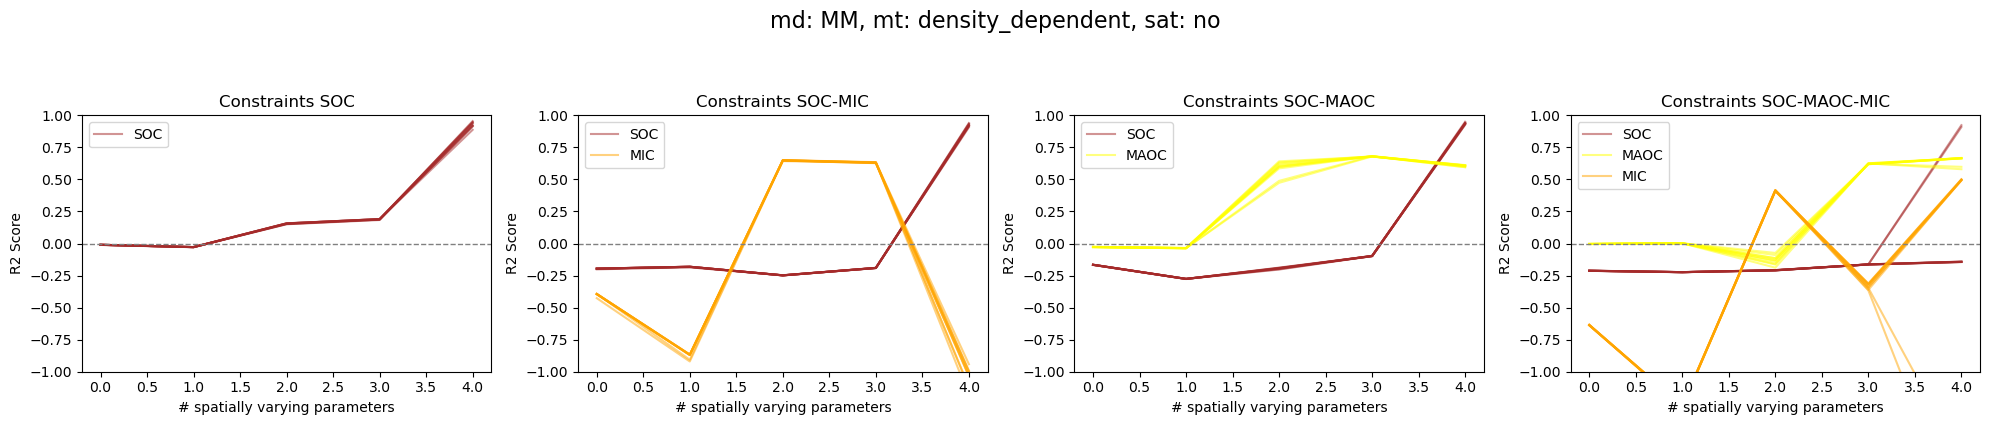

In [4]:
import matplotlib.pyplot as plt

def full_plot(temp, md, mt, sat, train_val_test):
    target_sets = ['SOC', 'SOC-MIC', 'SOC-MAOC', 'SOC-MAOC-MIC']  # 4 columns
    all_targets = ['SOC', 'MAOC', 'MIC']  # 3 possible targets, now as lines
    # Define colors per target
    target_colors = {'SOC': 'brown', 'MAOC': 'yellow', 'MIC': 'orange'}
    # Only one row, columns per constraint set
    fig, axs = plt.subplots(1, len(target_sets), figsize=(5 * len(target_sets), 4), squeeze=False)
    # Add parent plot title (md, mt, sat)
    fig.suptitle(f"md: {md}, mt: {mt}, sat: {sat}", fontsize=16, y=1.05)
    for col_idx, targets in enumerate(target_sets):
        split_targets = targets.split('-')
        ax = axs[0, col_idx]
        for target in all_targets:
            if target in split_targets:
                all_scores = []
                for fold in range(10):
                    fold_results = get_all_n_sp(
                        temp, fold, md, mt, sat, targets, train_val_test)
                    fold_target_r2s = [x[target] for x in fold_results if target in x]
                    all_scores.append(fold_target_r2s)
                # Plot all folds for this target in its color
                for i, fold_scores in enumerate(all_scores):
                    ax.plot(
                        range(len(fold_scores)), 
                        fold_scores, 
                        color=target_colors[target],
                        alpha=0.5,
                        label=f'{target} fold {i+1}' if i == 0 else ""  # Only label once for legend
                    )
        # Add a horizontal line at y=0
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel("# spatially varying parameters")
        ax.set_ylabel("R2 Score")
        ax.set_title(f"Constraints {targets}")
        ax.set_ylim(-1, 1)  # Force y axis between -1 and 1
        # Show color legend just once per target
        handles, labels = ax.get_legend_handles_labels()
        new_handles_labels = {}
        for handle, label in zip(handles, labels):
            if label and label.split()[0] not in new_handles_labels:
                new_handles_labels[label.split()[0]] = handle
        ax.legend(new_handles_labels.values(), new_handles_labels.keys())
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Make room for suptitle above

full_plot('static', 'MM', 'density_dependent', 'no', 'test')

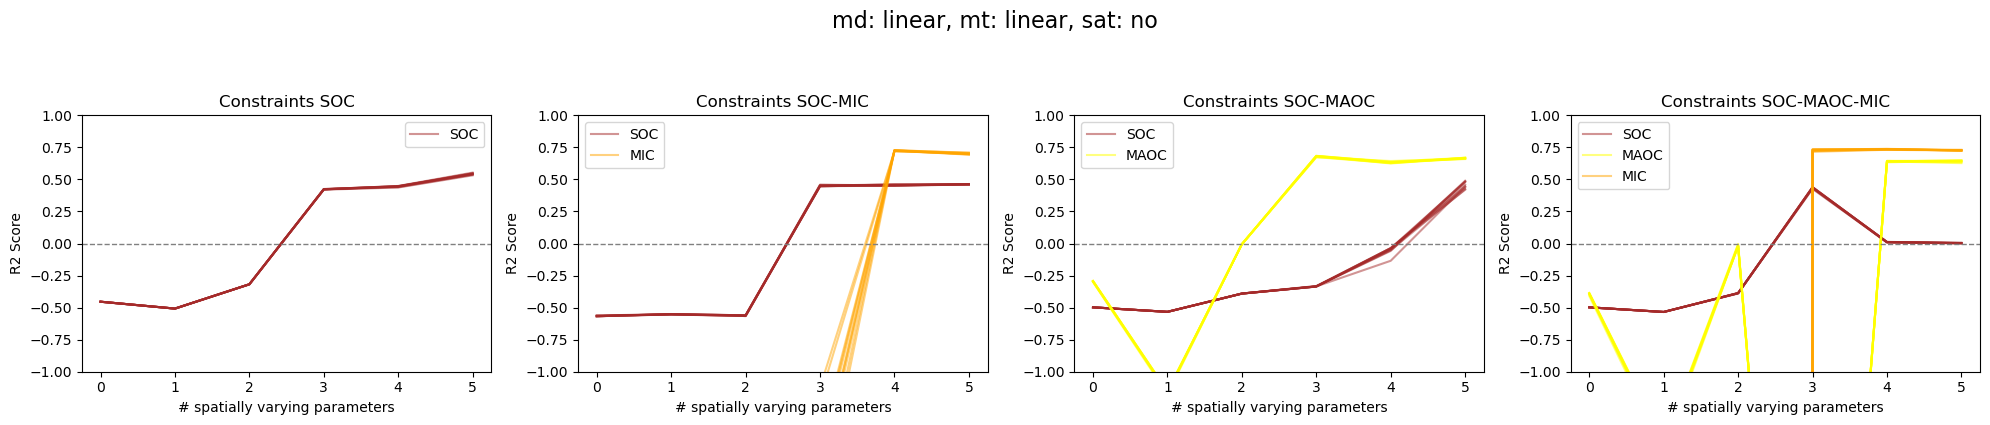

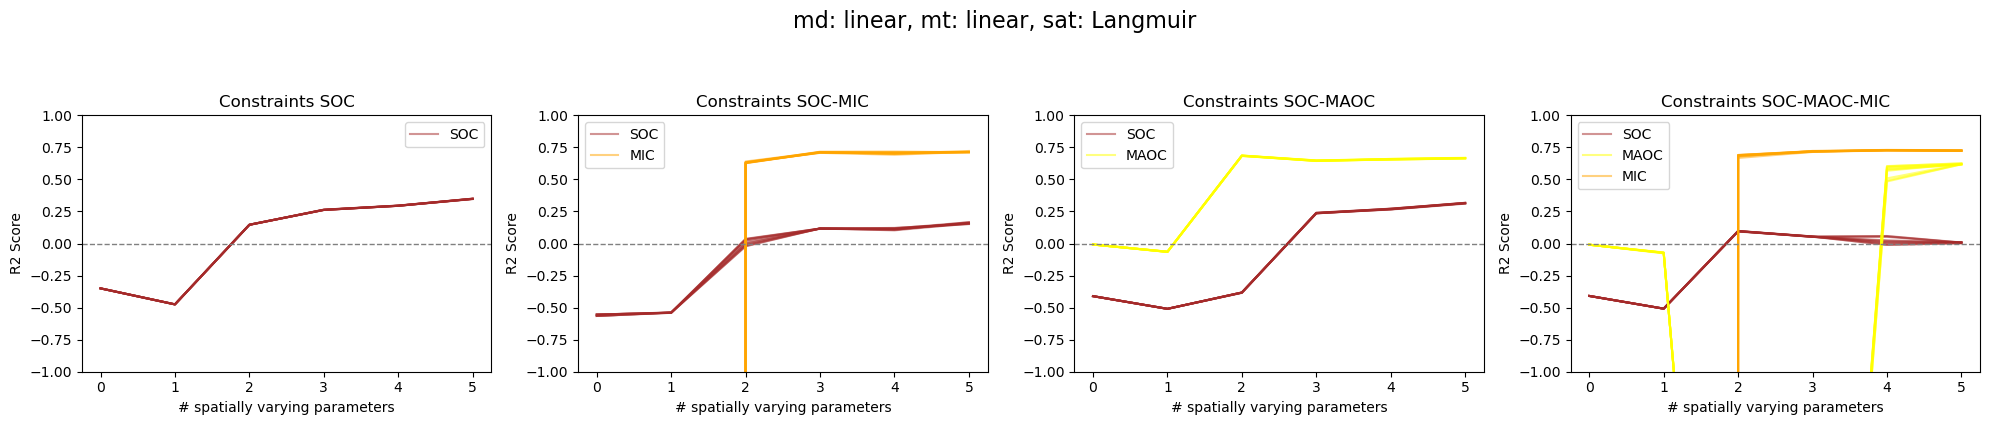

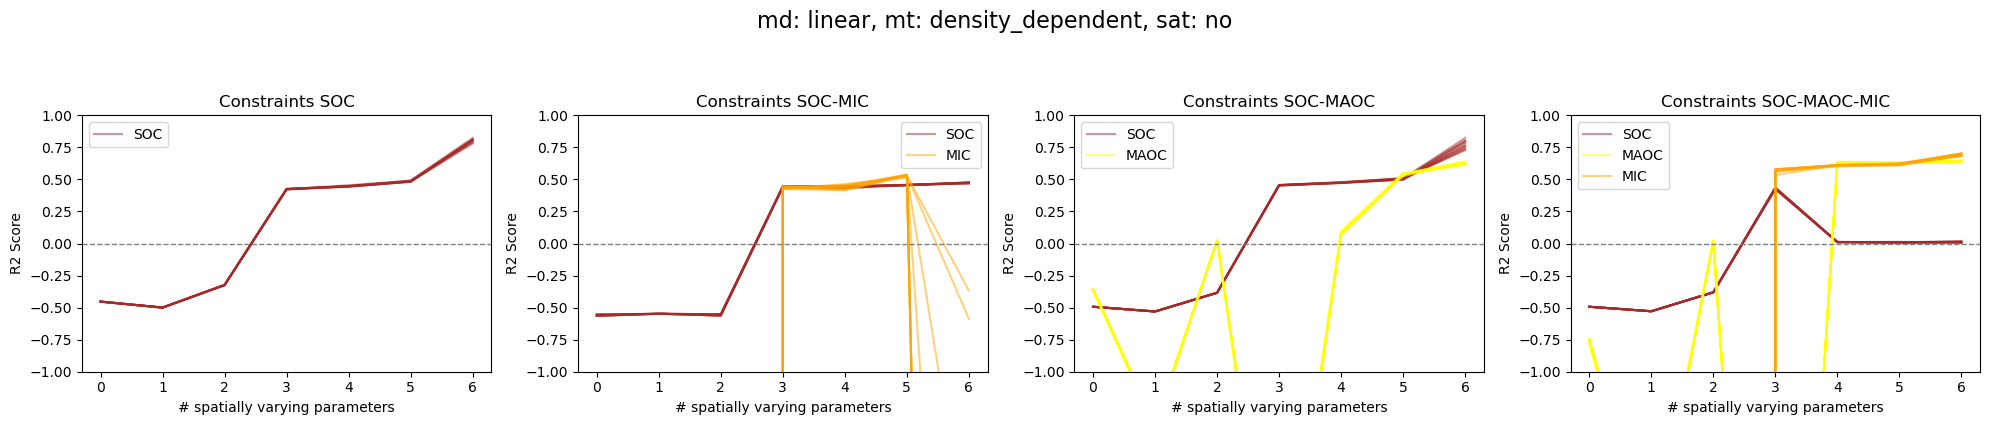

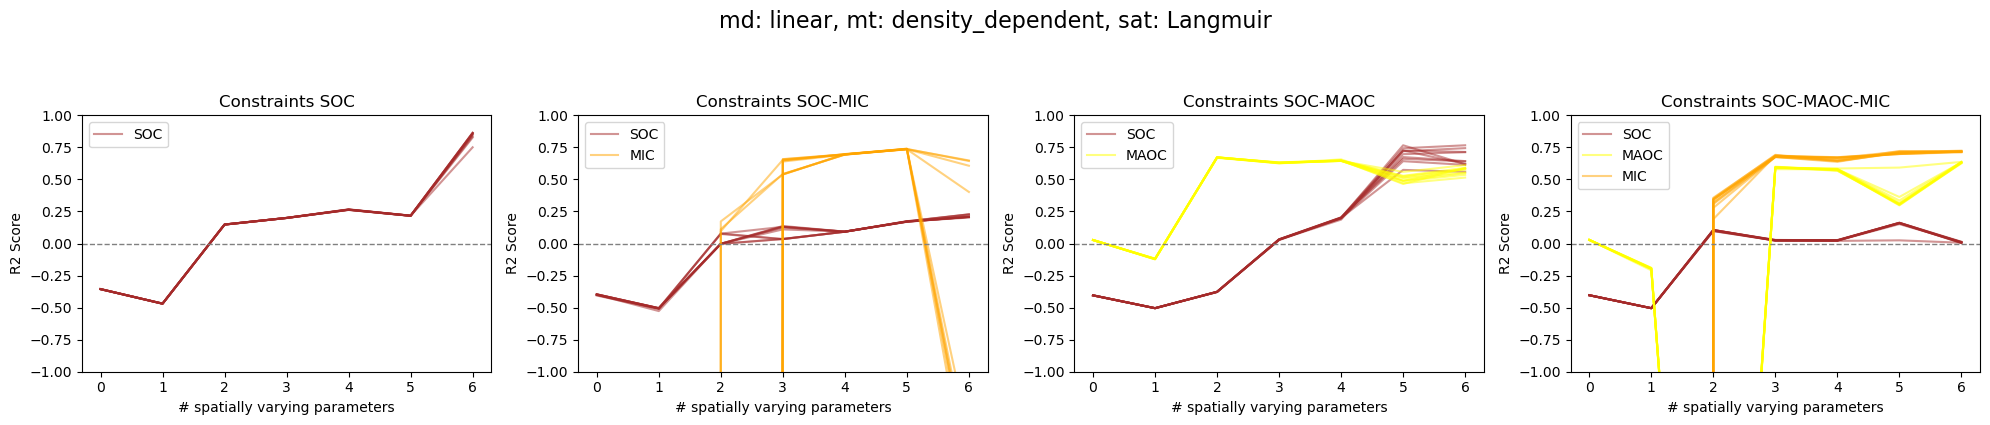

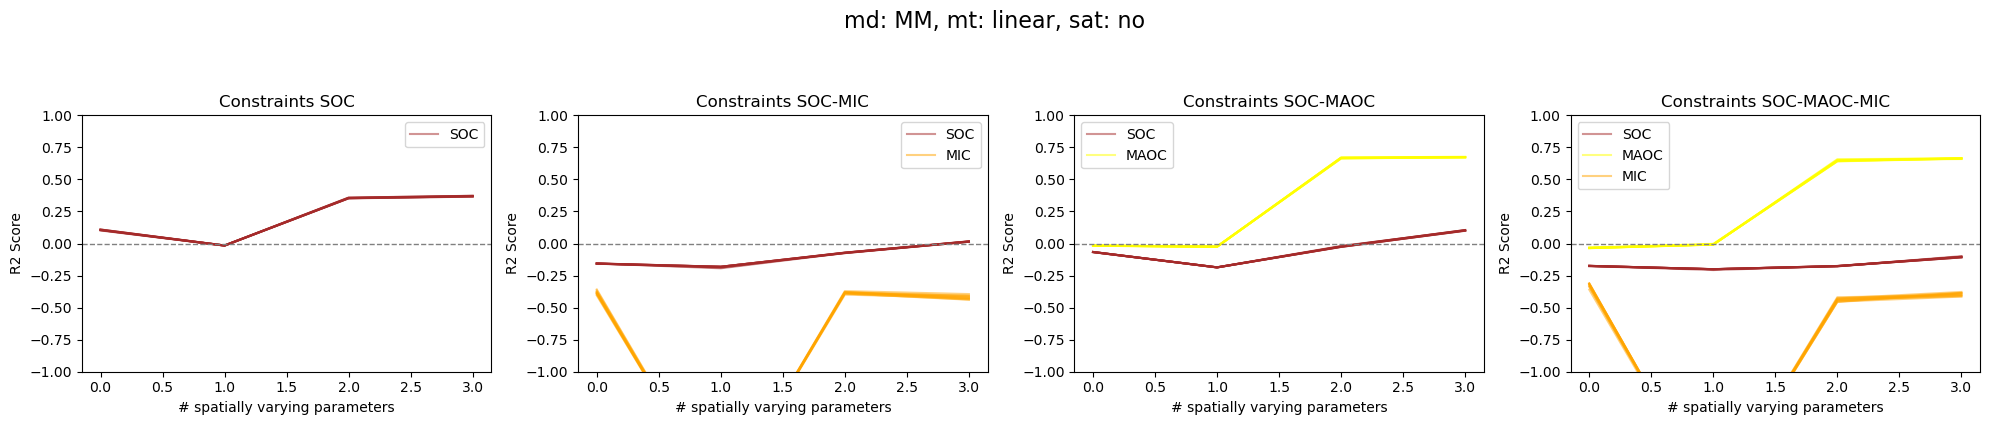

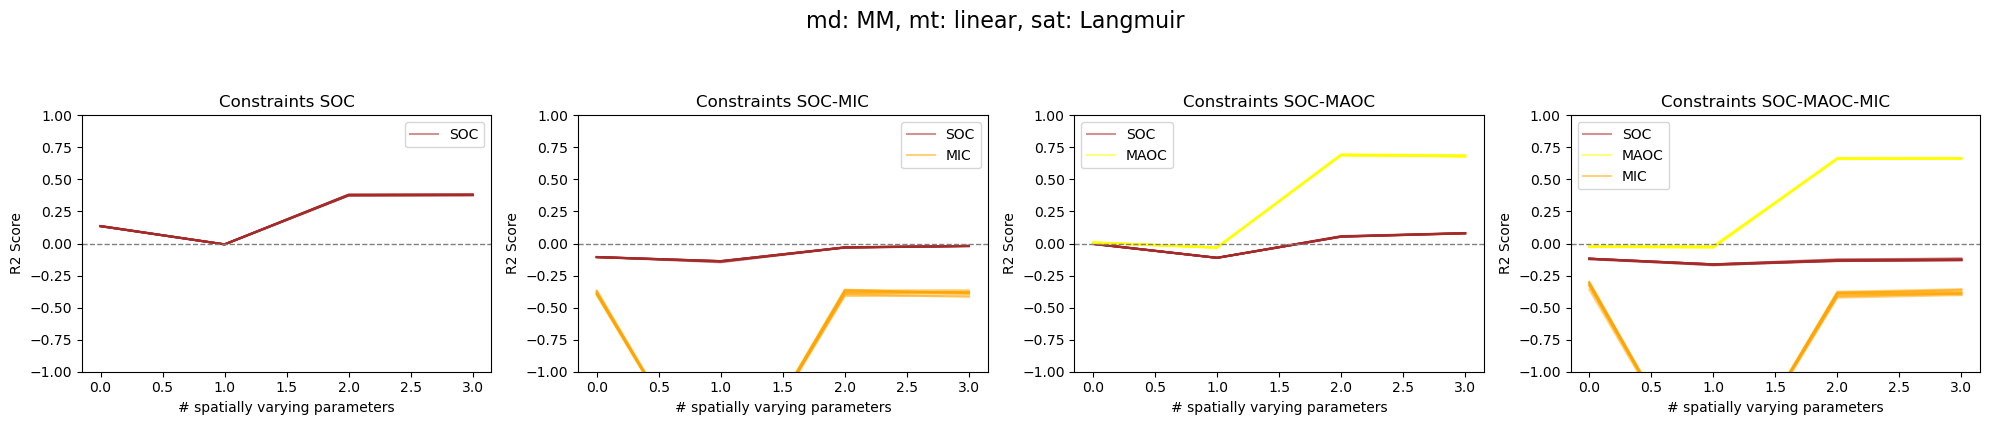

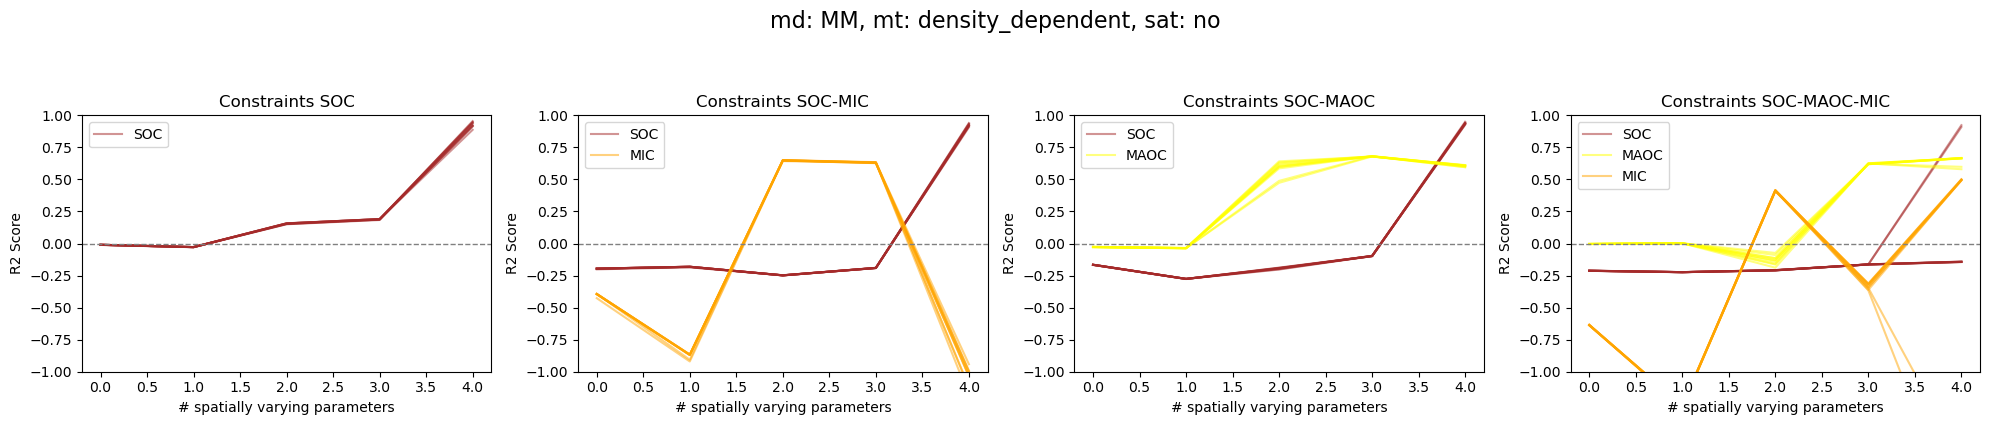

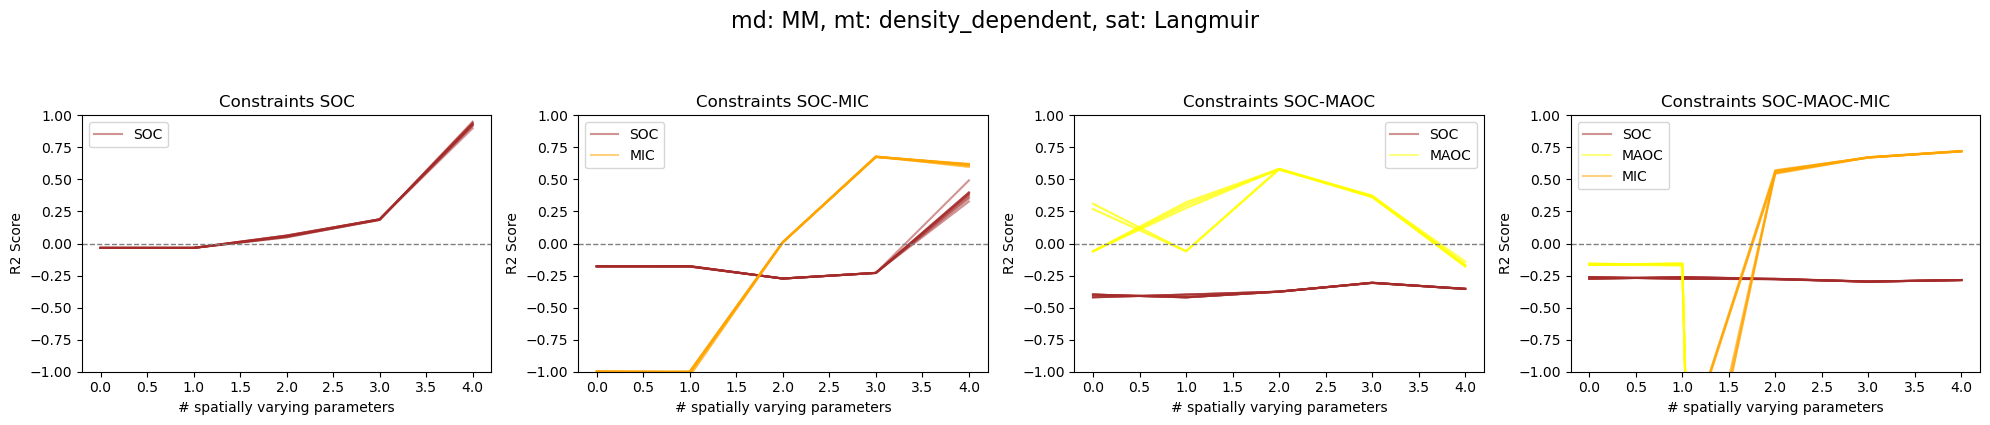

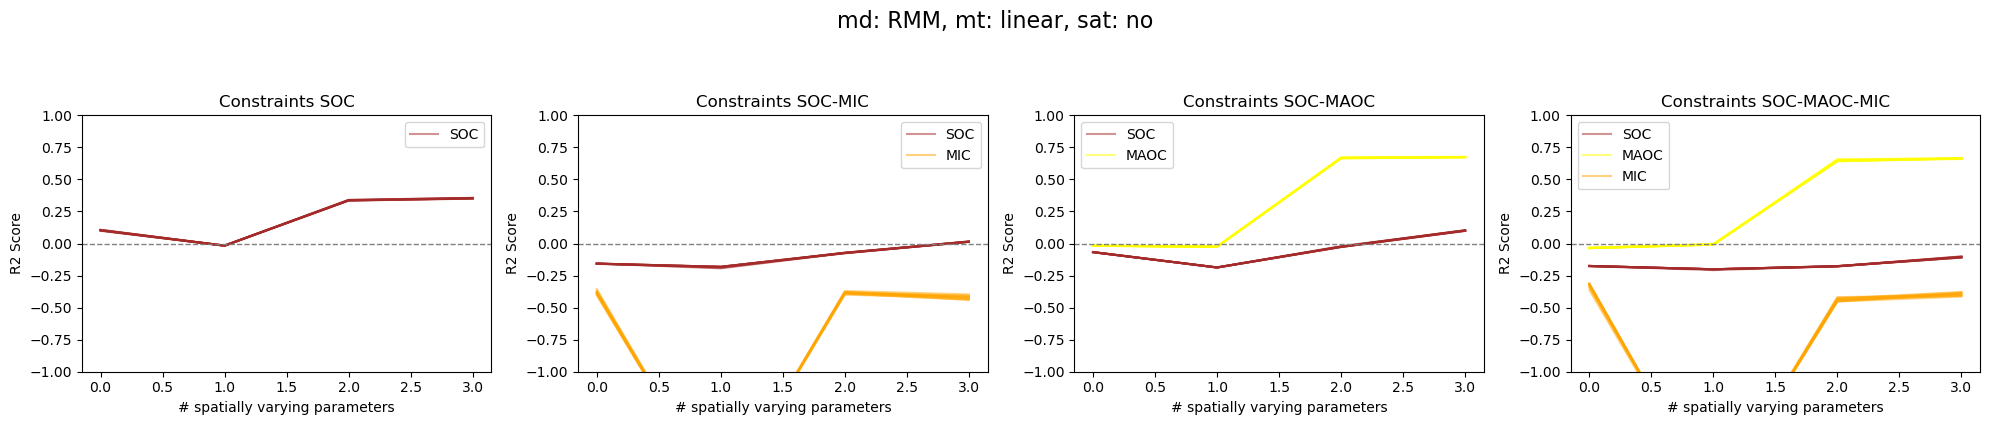

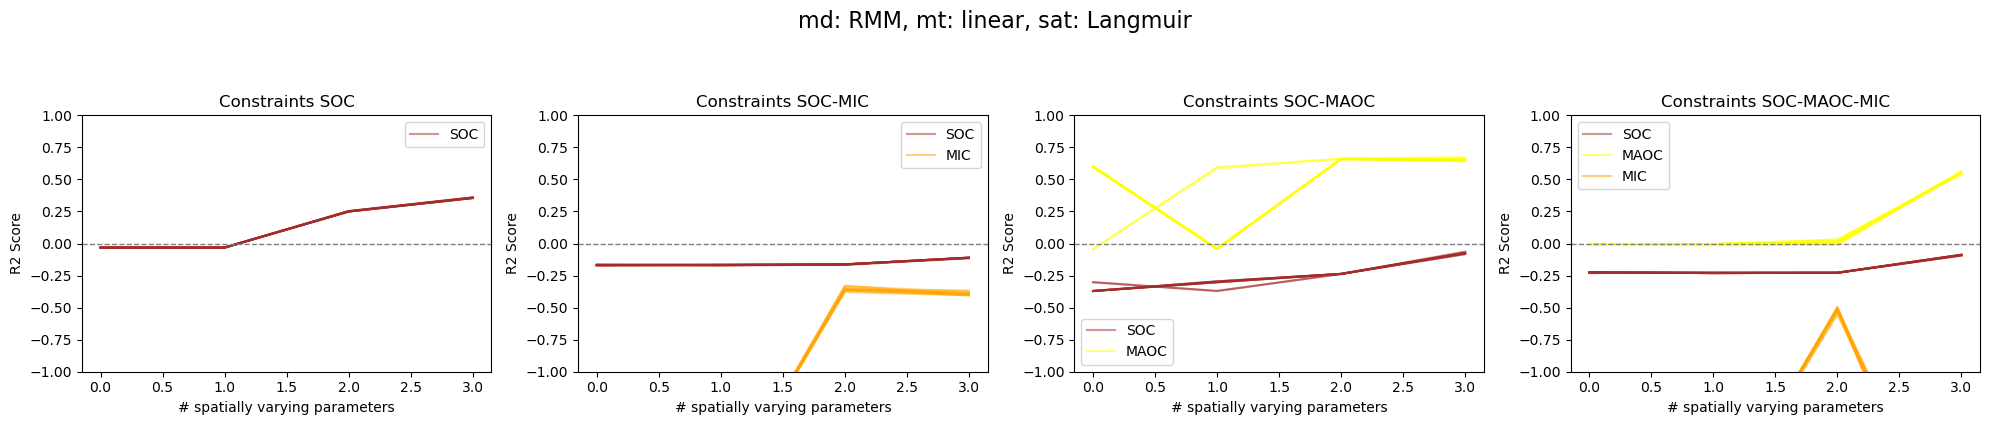

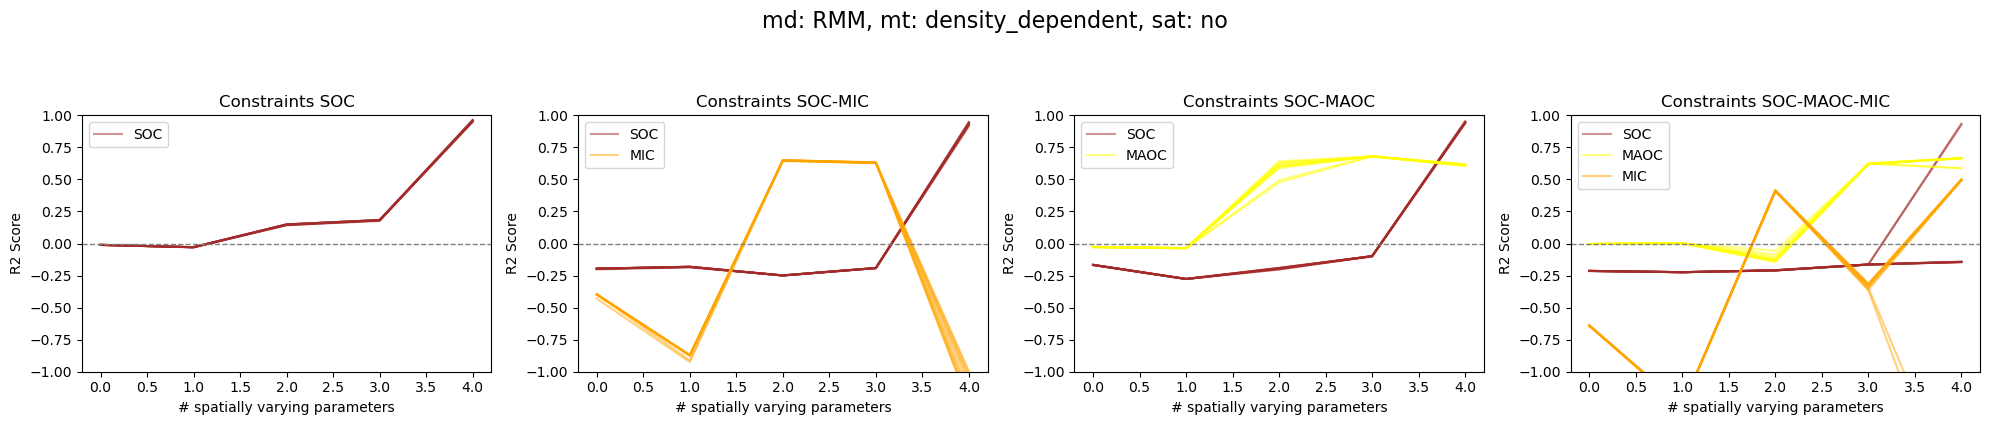

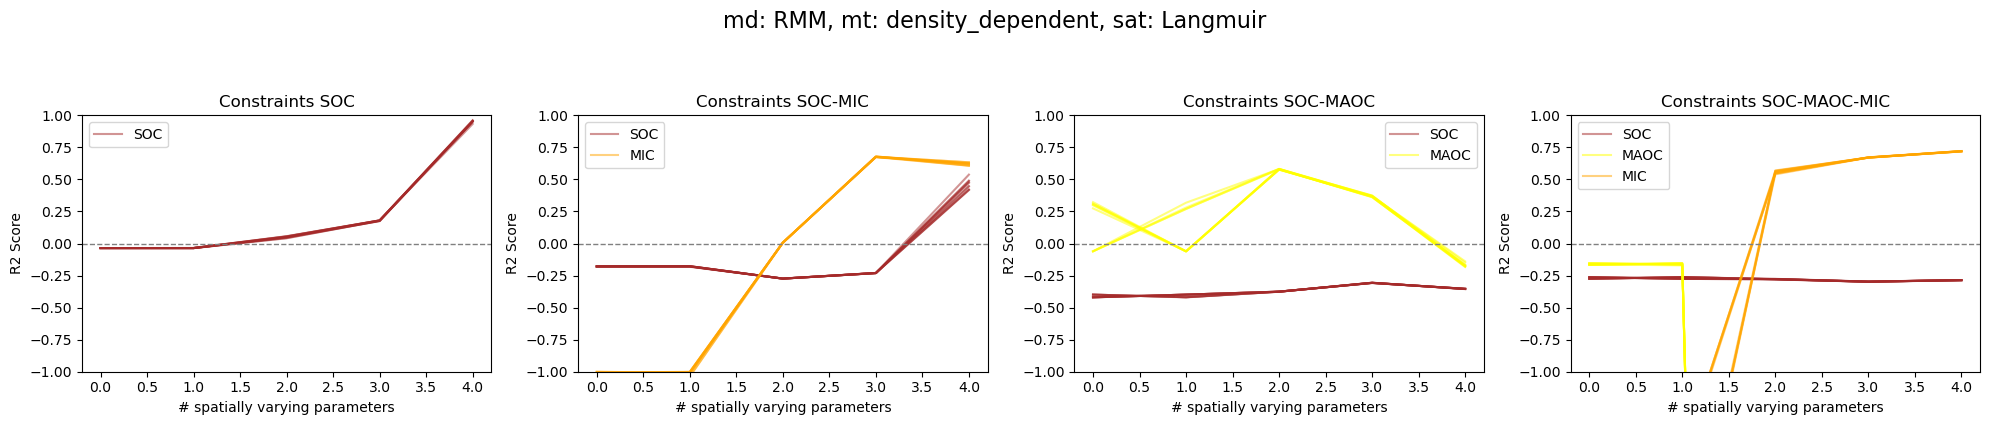

In [5]:
for md in ['linear', 'MM', 'RMM']:
    for mt in ['linear', 'density_dependent']:
        for sat in ['no', 'Langmuir']:
            full_plot('static', md, mt, sat, 'test')